# Phase 3: Model 1 - Logistic Regression Baseline

## Objective
Establish baseline performance for accident cause code classification using a simple, interpretable multi-class logistic regression model with a scikit-learn Pipeline.

## Approach
- **Model:** Logistic Regression (multi-class, one-vs-rest)
- **Pipeline:** OneHotEncoder -> StandardScaler -> LogisticRegression
- **Features:** 6 selected features from Phase 2 EDA
- **Target:** Cause_Category (E, H, M, S, T)
- **Validation:** 5-fold Stratified Cross-Validation on 80% training set
- **Evaluation:** Weighted F1-score, per-class precision/recall, confusion matrix
- **Experiments:** Baseline vs class-weighted model

---

## Setup

Import required libraries and set random seed for reproducibility. All random operations throughout this notebook use `RANDOM_SEED = 521` to ensure consistent results across runs.

All plots use the `tableau-colorblind10` colour cycle following CTAO best practices for colour-blind-friendly publications (CTAO, 2020). Cause categories are assigned fixed colours and hatch patterns so they can be identified through multiple visual channels.

In [14]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    precision_score, recall_score
)

import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
style.use('tableau-colorblind10')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_SEED = 521
np.random.seed(RANDOM_SEED)

# Consistent visual identity for cause categories across all plots
CAUSE_STYLES = {
    'E': {'label': 'Environmental', 'hatch': '//'},
    'H': {'label': 'Human Factor',  'hatch': '..'},
    'M': {'label': 'Mechanical',    'hatch': 'xx'},
    'S': {'label': 'Signal',        'hatch': '\\\\'},
    'T': {'label': 'Track',         'hatch': '++'},
}
CAUSE_ORDER = ['E', 'H', 'M', 'S', 'T']

## Load Training Data

Load the 80% training set from Phase 2. The 20% test set remains locked until final evaluation. Model selection and validation are handled entirely through cross-validation on this training set.

In [15]:
df_train = pd.read_csv('../data/splits/train_80.csv', low_memory=False)

print(f"Training set: {len(df_train)} rows")
print(f"\nCause_Category distribution:")
print(df_train['Cause_Category'].value_counts(normalize=True).round(3))

Training set: 27640 rows

Cause_Category distribution:
Cause_Category
H    0.393
M    0.256
T    0.218
E    0.108
S    0.025
Name: proportion, dtype: float64


## Feature Selection

Select 6 features from Phase 2 EDA. These were validated through Chi-Square independence tests and Cramer's V association strength analysis. All features showed statistically significant associations with Cause_Category after Bonferroni correction.

Features are split into categorical (for OneHotEncoding) and numeric (passed through directly) types for the sklearn ColumnTransformer.

**Note:** Accident Type is included in this baseline for comparison purposes. Phase 2 analysis identified it as a dominant confounding variable (Cramer's V = 0.39, nearly double the next strongest feature). A separate experiment will evaluate performance with and without it.

In [16]:
# Define feature sets by type
categorical_features = [
    'Weather Condition',
    'Track Type',
    'Visibility',
    'Accident Type',
    'Region'
]

numeric_features = [
    'RUCC_2023'
]

all_features = categorical_features + numeric_features
target = 'Cause_Category'

X_train = df_train[all_features].copy()
y_train = df_train[target].copy()

print(f"Features: {len(all_features)}")
print(f"  Categorical: {categorical_features}")
print(f"  Numeric: {numeric_features}")
print(f"\nTarget classes: {sorted(y_train.unique())}")
print(f"Training samples: {len(X_train)}")

Features: 6
  Categorical: ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type', 'Region']
  Numeric: ['RUCC_2023']

Target classes: ['E', 'H', 'M', 'S', 'T']
Training samples: 27640


## Build Sklearn Pipeline

The pipeline handles all preprocessing and modeling in a single object, preventing data leakage during cross-validation. Each CV fold fits the encoders and scaler only on its training portion.

**Pipeline steps:**
1. **ColumnTransformer:** OneHotEncoder for categorical features (creates dummy variables), passthrough for numeric features
2. **StandardScaler:** Normalizes all features to zero mean and unit variance. LR benefits from scaled features because the L-BFGS optimizer converges faster when features are on similar scales.
3. **LogisticRegression:** Multi-class classifier with default L2 regularization

Using `handle_unknown='ignore'` in OneHotEncoder so unseen categories in validation folds produce zero vectors instead of errors.

In [17]:
# Preprocessing: OneHot for categoricals, passthrough for numerics
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Baseline pipeline: default LR with L2 penalty
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_SEED
    ))
])

print("Baseline pipeline built:")
print(baseline_pipeline)

Baseline pipeline built:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Weather Condition',
                                                   'Track Type', 'Visibility',
                                                   'Accident Type', 'Region']),
                                                 ('num', 'passthrough',
                                                  ['RUCC_2023'])])),
                ('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=521))])


## How Logistic Regression Works

### The Core Idea

Logistic Regression answers a classification question using a regression framework. It starts with the same linear equation as ordinary linear regression - a weighted sum of features plus an intercept:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

In ordinary linear regression, z is the prediction. The problem is z can be any number from negative infinity to positive infinity, which doesn't work for classification where we need a probability between 0 and 1. Logistic Regression solves this by passing z through the **logistic function** (also called the sigmoid function):

$$P(y = 1) = \frac{1}{1 + e^{-z}}$$

This function takes any real number and squashes it into the range (0, 1). Large positive z values get pushed toward 1.0. Large negative z values get pushed toward 0.0. At z = 0, the output is exactly 0.5. The result is a probability estimate: "given these feature values, what is the probability this row belongs to class 1?"

### What the Coefficients Mean

Each coefficient ($\beta$) represents how much one unit of change in that feature shifts the log-odds of the outcome. Log-odds is the natural logarithm of the odds ratio:

$$\log\left(\frac{P}{1 - P}\right) = \beta_0 + \beta_1 x_1 + ... + \beta_n x_n$$

A positive coefficient means that feature increases the probability of the target class. A negative coefficient decreases it. The magnitude tells you how strong the effect is. For example, if the coefficient for Track Type_Main is 0.20, then being on main track (versus the reference category) increases the log-odds of that cause category by 0.20, holding all other features constant.

### Multi-Class Extension: Multinomial with Softmax

The logistic function described above handles binary classification (two classes). Our project has 5 accident cause categories. Sklearn handles this using a **multinomial** approach with the **softmax function**: instead of training 5 separate binary classifiers, it trains a single model that simultaneously estimates the probability of all 5 classes.

The softmax function generalizes the logistic function to multiple classes. For each class k, it computes:

$$P(y = k) = \frac{e^{z_k}}{\sum_{j=1}^{5} e^{z_j}}$$

where $z_k$ is the linear score for class k. The denominator ensures all 5 probabilities sum to 1.0. The class with the highest probability becomes the prediction for that row. If a row's softmax outputs are Environmental 0.08, Human Factor 0.45, Mechanical 0.30, Signal 0.02, Track 0.15, the model predicts Human Factor.

Each cause category still has its own set of coefficients - Environmental has weights that differ from Human Factor, which differ from Mechanical, and so on. This is why the L1 sparsity analysis in the tuning notebook could examine which features matter for each cause independently. The coefficients are learned jointly (the model optimizes all 5 classes at once), but each class maintains its own coefficient vector.

### How the Model Learns: Maximum Likelihood

Logistic Regression **finds the best coefficients by maximizing the likelihood** of its predictions on the training data. In plain terms: it adjusts the weights until the predicted probabilities best match what actually happened. If a row's true label is Human Factor, good coefficients should produce a high predicted probability for Human Factor and low probabilities for everything else.

The learning process is iterative. The algorithm starts with random coefficients, makes predictions, measures how wrong they are using **log-loss** (also called cross-entropy), and nudges the coefficients in the direction that reduces the error. Log-loss penalizes confident wrong predictions more heavily than uncertain ones - predicting "90% Human Factor" when the true label is Environmental costs more than predicting "40% Human Factor."

Our baseline uses the L-BFGS optimization algorithm, which is fast and works well with L2 regularization. However, the L1 sparsity experiments in the tuning notebook switched to the SAGA algorithm because L-BFGS cannot handle L1 penalties we experimented with. 

### Why One-Hot Encoding Matters

Our pipeline applies OneHotEncoder before fitting the model. This converts categorical features into binary columns (Track Type becomes Track Type_Main, Track Type_Yard, Track Type_Industry, Track Type_Siding). This step is necessary because the linear equation requires numeric inputs. Each binary column gets its own coefficient, allowing the model to learn that Main track has a different effect on cause prediction than Yard track.

After one-hot encoding, our 5 categorical features expand to 21 binary columns. This is the actual feature space the model works in - and it is what the L1 sparsity analysis (in the lr-tuning-experiments notebooks) examined when it found that different cause categories rely on different subsets of those 21 columns.

## 5-Fold Stratified Cross-Validation: Baseline

We run 5-fold stratified CV on the training set. Stratification ensures each fold preserves the class distribution (particularly important for Signal at 2.5% and Environmental at 11%). The pipeline handles encoding and scaling within each fold to prevent data leakage.

We report both the per-fold scores and the mean with standard deviation. A low standard deviation indicates the model performance is stable across different data partitions.

In [18]:
# 5-fold stratified CV for baseline
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

baseline_scores = []

print("Baseline LR - 5-Fold Stratified CV")
print("-" * 45)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]
    
    baseline_pipeline.fit(X_tr, y_tr)
    y_pred = baseline_pipeline.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='weighted')
    baseline_scores.append(f1)
    
    print(f"  Fold {fold}: Weighted F1 = {f1:.4f}")

baseline_mean = np.mean(baseline_scores)
baseline_std = np.std(baseline_scores)

print(f"\nBaseline CV: {baseline_mean:.4f} +/- {baseline_std:.4f}")

Baseline LR - 5-Fold Stratified CV
---------------------------------------------
  Fold 1: Weighted F1 = 0.5352
  Fold 2: Weighted F1 = 0.5320
  Fold 3: Weighted F1 = 0.5319
  Fold 4: Weighted F1 = 0.5356
  Fold 5: Weighted F1 = 0.5445

Baseline CV: 0.5358 +/- 0.0046


### Baseline CV Findings

Evaluate the stability of cross-validation scores. A standard deviation below 0.01 indicates highly stable performance across folds. The mean weighted F1 establishes our baseline benchmark.

## Experiment: Class-Weighted Model

Address class imbalance by applying `class_weight='balanced'`, which automatically adjusts weights inversely proportional to class frequencies. This penalizes the model more heavily for misclassifying rare classes (Signal at 2.5%, Environmental at 11%).

The hypothesis is that class weighting will improve recall on rare classes at the cost of precision on majority classes. Whether this trade-off improves overall weighted F1 is what we are testing.

In [19]:
# Balanced pipeline: same preprocessing, class-weighted LR
balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_SEED
    ))
])

balanced_scores = []

print("Balanced LR - 5-Fold Stratified CV")
print("-" * 45)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]
    
    balanced_pipeline.fit(X_tr, y_tr)
    y_pred = balanced_pipeline.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='weighted')
    balanced_scores.append(f1)
    
    print(f"  Fold {fold}: Weighted F1 = {f1:.4f}")

balanced_mean = np.mean(balanced_scores)
balanced_std = np.std(balanced_scores)

print(f"\nBalanced CV: {balanced_mean:.4f} +/- {balanced_std:.4f}")

Balanced LR - 5-Fold Stratified CV
---------------------------------------------
  Fold 1: Weighted F1 = 0.4603
  Fold 2: Weighted F1 = 0.4529
  Fold 3: Weighted F1 = 0.4509
  Fold 4: Weighted F1 = 0.4625
  Fold 5: Weighted F1 = 0.4591

Balanced CV: 0.4571 +/- 0.0045


## Model Comparison

Compare baseline vs class-weighted LR across all 5 folds. This determines which configuration to use as the final LR model.

In [20]:
print("=" * 50)
print("MODEL COMPARISON: Baseline vs Balanced")
print("=" * 50)
print(f"  Baseline CV:  {baseline_mean:.4f} +/- {baseline_std:.4f}")
print(f"  Balanced CV:  {balanced_mean:.4f} +/- {balanced_std:.4f}")
print(f"  Difference:   {balanced_mean - baseline_mean:+.4f}")

if baseline_mean > balanced_mean:
    best_name = 'Baseline'
    best_pipeline = baseline_pipeline
    best_mean = baseline_mean
    best_std = baseline_std
else:
    best_name = 'Balanced'
    best_pipeline = balanced_pipeline
    best_mean = balanced_mean
    best_std = balanced_std

print(f"\n  Best model: {best_name} (F1 = {best_mean:.4f})")

MODEL COMPARISON: Baseline vs Balanced
  Baseline CV:  0.5358 +/- 0.0046
  Balanced CV:  0.4571 +/- 0.0045
  Difference:   -0.0787

  Best model: Baseline (F1 = 0.5358)


## Final Model: Fit on Full Training Set

Refit the best pipeline on the entire 80% training set. This is the model that will be saved and evaluated on the locked test set in the final evaluation notebook. We generate detailed metrics using this full-data fit.

In [21]:
# Fit best pipeline on full training set
best_pipeline.fit(X_train, y_train)

# For detailed metrics, use the last CV fold's validation predictions
# Refit on all but last fold for a representative evaluation
last_train_idx, last_val_idx = list(skf.split(X_train, y_train))[-1]
X_eval = X_train.iloc[last_val_idx]
y_eval = y_train.iloc[last_val_idx]

best_pipeline.fit(X_train.iloc[last_train_idx], y_train.iloc[last_train_idx])
y_pred_eval = best_pipeline.predict(X_eval)

eval_f1 = f1_score(y_eval, y_pred_eval, average='weighted')

print(f"=== {best_name} Logistic Regression - Last Fold Evaluation ===")
print(f"Weighted F1-Score: {eval_f1:.4f}\n")
print(classification_report(y_eval, y_pred_eval, zero_division=0))

=== Baseline Logistic Regression - Last Fold Evaluation ===
Weighted F1-Score: 0.5445

              precision    recall  f1-score   support

           E       0.64      0.13      0.21       596
           H       0.55      0.79      0.65      2172
           M       0.90      0.49      0.64      1416
           S       0.00      0.00      0.00       139
           T       0.43      0.54      0.48      1205

    accuracy                           0.57      5528
   macro avg       0.50      0.39      0.39      5528
weighted avg       0.61      0.57      0.54      5528



## Per-Class Metrics (Secondary Metric)

Break down precision and recall by individual cause category. This reveals which causes the model predicts well versus poorly, and is critical for understanding rare class (S, E) performance.

In [22]:
precision_per_class = precision_score(y_eval, y_pred_eval, average=None, 
                                     labels=CAUSE_ORDER, zero_division=0)
recall_per_class = recall_score(y_eval, y_pred_eval, average=None, 
                                labels=CAUSE_ORDER, zero_division=0)
f1_per_class = f1_score(y_eval, y_pred_eval, average=None, 
                        labels=CAUSE_ORDER, zero_division=0)

metrics_df = pd.DataFrame({
    'Cause': CAUSE_ORDER,
    'Precision': precision_per_class.round(3),
    'Recall': recall_per_class.round(3),
    'F1': f1_per_class.round(3)
})

print("=== Per-Class Metrics ===")
print(metrics_df.to_string(index=False))

=== Per-Class Metrics ===
Cause  Precision  Recall    F1
    E      0.641   0.126 0.210
    H      0.547   0.790 0.646
    M      0.904   0.494 0.639
    S      0.000   0.000 0.000
    T      0.431   0.536 0.478


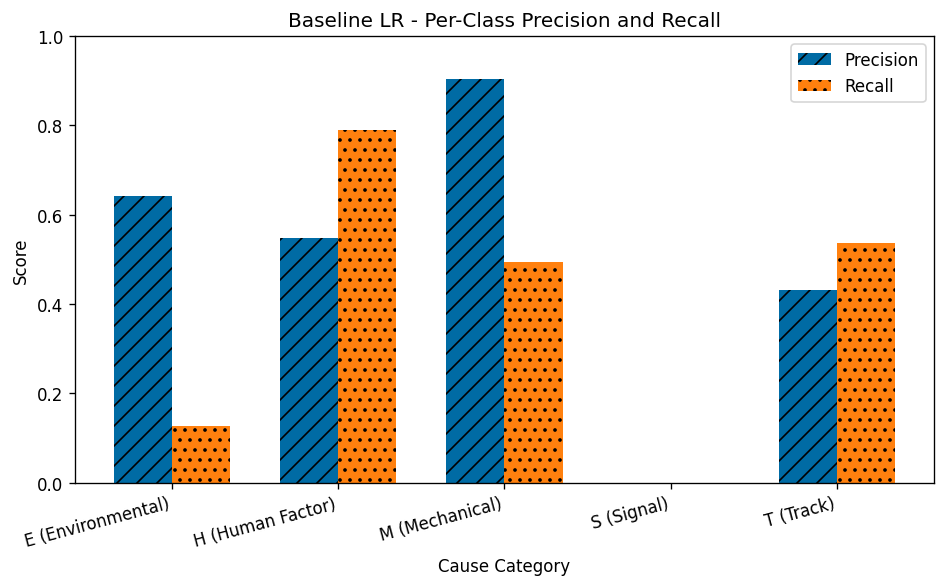

In [23]:
# Per-class precision and recall bar chart
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(CAUSE_ORDER))
width = 0.35

bars_p = ax.bar(x - width/2, metrics_df['Precision'], width, label='Precision')
bars_r = ax.bar(x + width/2, metrics_df['Recall'], width, label='Recall')

# Add hatch patterns for accessibility
for bar in bars_p:
    bar.set_hatch('//')
for bar in bars_r:
    bar.set_hatch('..')

ax.set_xlabel('Cause Category')
ax.set_ylabel('Score')
ax.set_title(f'{best_name} LR - Per-Class Precision and Recall')
ax.set_xticks(x)
ax.set_xticklabels([f"{c} ({CAUSE_STYLES[c]['label']})" for c in CAUSE_ORDER], 
                    rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## Confusion Matrix (Tertiary Metric)

Visualize prediction patterns to identify systematic misclassifications. Darker cells on the diagonal indicate correct predictions. Off-diagonal cells reveal which cause categories the model confuses with each other.

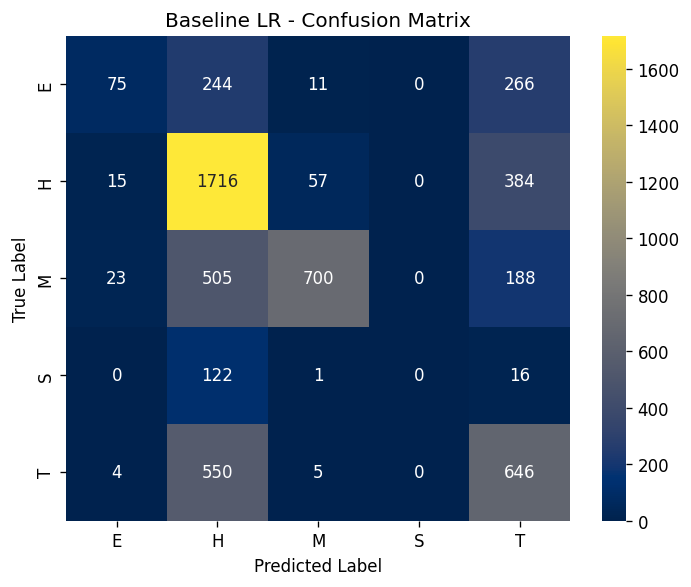

In [24]:
cm = confusion_matrix(y_eval, y_pred_eval, labels=CAUSE_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis',
            xticklabels=CAUSE_ORDER, yticklabels=CAUSE_ORDER, ax=ax)
ax.set_title(f'{best_name} LR - Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Cross-Validation Score Comparison

Visualize the per-fold F1 scores for both models. Horizontal dashed lines show the mean. Overlapping ranges indicate the models perform similarly; separation indicates a meaningful difference.

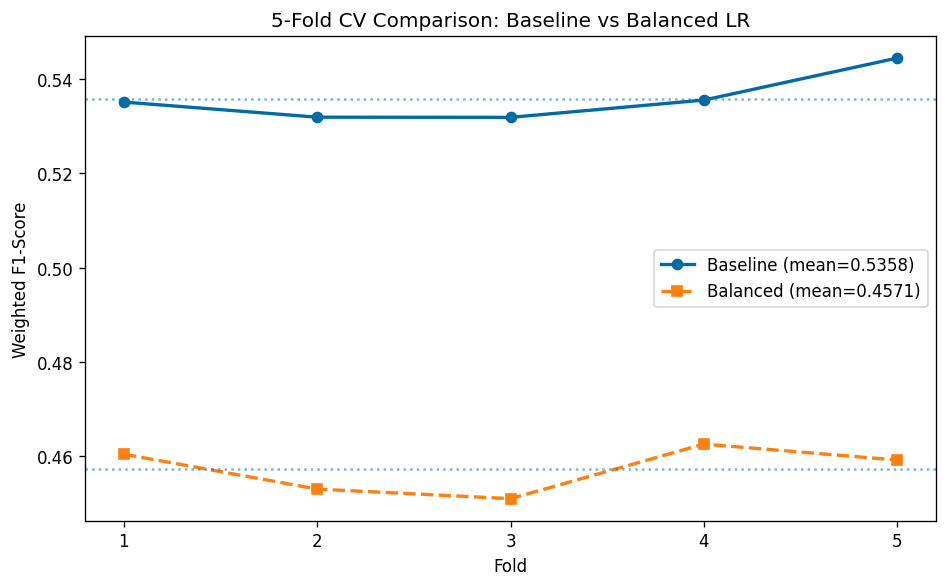

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

folds = np.arange(1, 6)

ax.plot(folds, baseline_scores, marker='o', linewidth=2, 
        label=f'Baseline (mean={baseline_mean:.4f})', linestyle='-')
ax.plot(folds, balanced_scores, marker='s', linewidth=2,
        label=f'Balanced (mean={balanced_mean:.4f})', linestyle='--')

ax.axhline(y=baseline_mean, linestyle=':', alpha=0.5)
ax.axhline(y=balanced_mean, linestyle=':', alpha=0.5)

ax.set_xlabel('Fold')
ax.set_ylabel('Weighted F1-Score')
ax.set_title('5-Fold CV Comparison: Baseline vs Balanced LR')
ax.set_xticks(folds)
ax.legend()

plt.tight_layout()
plt.show()

## Save Model and Results

Save the best-performing pipeline and evaluation metrics for use in the final evaluation notebook. The pipeline includes all preprocessing steps (encoding, scaling) so it can be applied directly to new data without separate transformation.

In [26]:
# Refit best pipeline on full training data before saving
best_pipeline.fit(X_train, y_train)

# Save pipeline (includes preprocessor + scaler + model)
joblib.dump(best_pipeline, '../models/lr_baseline_pipeline.pkl')
print(f"Saved: ../models/lr_baseline_pipeline.pkl")

# Save results (standardized format matching tuning experiment JSONs)
results = {
    'experiment': 'LR Baseline (with Accident Type)',
    'model': 'Logistic Regression',
    'features': {
        'categorical': categorical_features,
        'numeric': numeric_features,
        'total': len(categorical_features) + len(numeric_features)
    },
    'cv_folds': 5,
    'cv_scores': [float(s) for s in baseline_scores],
    'cv_mean': float(baseline_mean),
    'cv_std': float(baseline_std),
    'per_class_metrics': metrics_df.to_dict('records'),
    'random_seed': RANDOM_SEED,
    'balanced_cv_mean': float(balanced_mean),
    'balanced_cv_std': float(balanced_std),
    'balanced_cv_scores': [float(s) for s in balanced_scores]
}

with open('../results/lr/lr_baseline_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print(f"Saved: ../results/lr/lr_baseline_results.json")

Saved: ../models/lr_baseline_pipeline.pkl
Saved: ../results/lr/lr_baseline_results.json


## Summary

This notebook established the Logistic Regression baseline for cause category classification using a scikit-learn Pipeline with OneHotEncoding, StandardScaling, and 5-fold stratified cross-validation.

**Key results:**
- Baseline and balanced class-weight models were compared via CV
- Best model and metrics saved for final evaluation
- Pipeline encapsulates all preprocessing, preventing data leakage

**Limitations:**
- Uses default L2 regularization and L-BFGS solver
- SAGA solver with L1 penalty (feature selection via sparsity) is a candidate for exploratory experiments
- Feature set includes Accident Type, which Phase 2 identified as a dominant confounding variable - a separate experiment will compare performance with and without it

**Next steps:**
- Exploratory notebook: Track Type vs Signalization feature comparison
- Exploratory notebook: SAGA L1 regularization experiment
- Exploratory notebook: Feature set without Accident Type
- CBA and Random Forest baseline notebooks